# Libraries

In [ ]:
%matplotlib

import requests
import pandas as pd
import numpy as np
import random
from math import radians, cos, sin, sqrt, atan2
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import KMeans
import pickle

# Setup config

In [2]:
api_key = ''

source_lat = 35.9375
source_lng = 14.3754
location = f'{source_lat}, {source_lng}'  # Latitude and longitude of Malta
radius = 50000  # Search radius in meters

queries = ['tourist attractions', 'sightseeing landmarks', 'point of interests', 'iconic sites', 'scenic points', 'popular destinations', 'archaeological site', 'historical landmark', 'nature attractions']

# Fetch locations from API

In [3]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in kilometers
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c  # Distance in kilometers

In [4]:
df_places = pd.DataFrame()
for query in queries:
    url = f"https://maps.googleapis.com/maps/api/place/textsearch/json?query={query}&location={location}&radius={radius}&key={api_key}&strictbounds"
    response = requests.get(url)
    data = response.json()
    
    places = []
    for result in data['results']:
        lat = result['geometry']['location']['lat']
        lng = result['geometry']['location']['lng']
        name = result['name']
        address = result.get('formatted_address', 'N/A')
        types = ", ".join(result.get('types', []))

        distance_from_centre = haversine(source_lat, source_lng, lat, lng) * 1000 # Convert to meters
        if distance_from_centre <= radius:
            places.append({'Latitude': lat, 'Longitude': lng, 'Name': name, 'Address': address, 'Types': types})

    df = pd.DataFrame(places)
    df_places = pd.concat([df_places, df], axis=0)

df_places = df_places.drop_duplicates().reset_index(drop=True)
df_places

,Latitude,Longitude,Name,Address,Types
0,35.853135,14.443159,"The Limestone Heritage, Park and Gardens","Limestone Heritage Siggiewi, SGW 2050, Malta","tourist_attraction, point_of_interest, establi..."
1,35.884787,14.403527,The Mdina Dungeons Museum,"St. Publius Square, L-Imdina, Malta","tourist_attraction, museum, point_of_interest,..."
2,35.899805,14.518718,The Malta Experience,"St Elmo Bastions, Mediterranean Street, Il-Bel...","tourist_attraction, point_of_interest, establi..."
3,35.897436,14.512244,Malta Fun Train | Valletta,"Triq San Gwann, Il-Belt Valletta, Malta","tourist_attraction, point_of_interest, establi..."
4,35.890091,14.508003,The Valletta Waterfront,"Triq il-Vittmi Furjaniżi tal-Gwerra, Il-Furjan...","tourist_attraction, point_of_interest, establi..."
...,...,...,...,...,...
120,35.944737,14.366682,Public Nature Reserve,"W9V8+VMV, Mellieħa, Malta","park, point_of_interest, establishment"
121,35.945845,14.381564,Simar Nature Reserve,"Triq il-Pwales Xemxija, San Pawl il-Baħar, SPB...","zoo, park, point_of_interest, establishment"
122,35.815730,14.472701,Wied il-Bassasa,"RF8F+73W, Żurrieq, Malta","tourist_attraction, park, point_of_interest, e..."
123,35.925578,14.343262,Snorkeling point,"W8GV+68J, Unnamed Road, Mġarr, Malta","park, point_of_interest, establishment"


In [5]:
for index, row in df_places.iterrows():
    print(f'Place {index: <5} | Location: {row['Name']: <45} | Address: {row['Address']: <10}') 
    print(f'Type: {row['Types']}')
    print('-'*150)

Place 0     | Location: The Limestone Heritage, Park and Gardens      | Address: Limestone Heritage Siggiewi, SGW 2050, Malta
Type: tourist_attraction, point_of_interest, establishment
------------------------------------------------------------------------------------------------------------------------------------------------------
Place 1     | Location: The Mdina Dungeons Museum                     | Address: St. Publius Square, L-Imdina, Malta
Type: tourist_attraction, museum, point_of_interest, establishment
------------------------------------------------------------------------------------------------------------------------------------------------------
Place 2     | Location: The Malta Experience                          | Address: St Elmo Bastions, Mediterranean Street, Il-Belt Valletta VLT 1253, Malta
Type: tourist_attraction, point_of_interest, establishment
--------------------------------------------------------------------------------------------------------------------

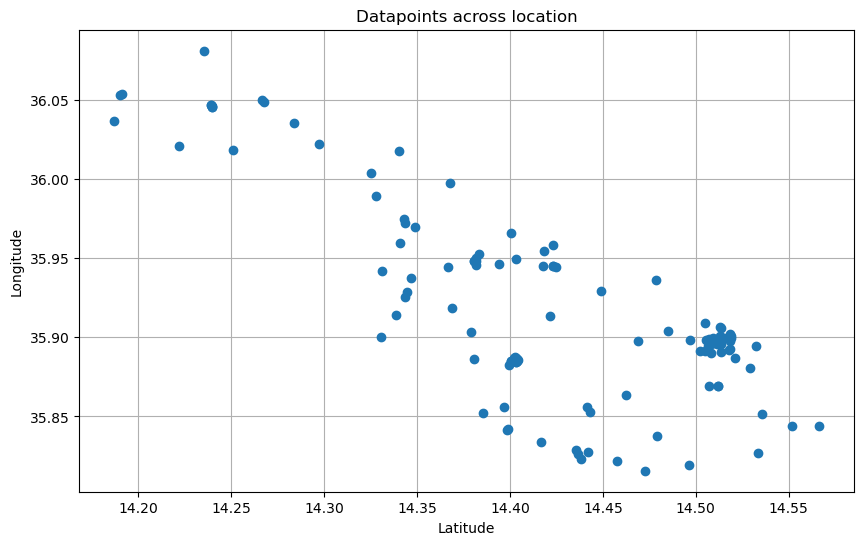

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(df_places['Longitude'], df_places['Latitude'], zorder=2)
plt.title('Datapoints across location')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.grid(zorder=3)
plt.show()

# Unsupervised Learning via Clustering

In [7]:
kmeans_classifier = KMeans(
    n_clusters=7,
    init='random',
    max_iter=500,
    random_state=42
)

In [8]:
predicted_clusters = kmeans_classifier.fit_predict(df_places[['Latitude','Longitude']])

C:\Users\Mark\.conda\envs\tensorflow_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [9]:
df_places['Day'] = predicted_clusters
df_places

,Latitude,Longitude,Name,Address,Types,Day
0,35.853135,14.443159,"The Limestone Heritage, Park and Gardens","Limestone Heritage Siggiewi, SGW 2050, Malta","tourist_attraction, point_of_interest, establi...",2
1,35.884787,14.403527,The Mdina Dungeons Museum,"St. Publius Square, L-Imdina, Malta","tourist_attraction, museum, point_of_interest,...",0
2,35.899805,14.518718,The Malta Experience,"St Elmo Bastions, Mediterranean Street, Il-Bel...","tourist_attraction, point_of_interest, establi...",6
3,35.897436,14.512244,Malta Fun Train | Valletta,"Triq San Gwann, Il-Belt Valletta, Malta","tourist_attraction, point_of_interest, establi...",6
4,35.890091,14.508003,The Valletta Waterfront,"Triq il-Vittmi Furjaniżi tal-Gwerra, Il-Furjan...","tourist_attraction, point_of_interest, establi...",6
...,...,...,...,...,...,...
120,35.944737,14.366682,Public Nature Reserve,"W9V8+VMV, Mellieħa, Malta","park, point_of_interest, establishment",5
121,35.945845,14.381564,Simar Nature Reserve,"Triq il-Pwales Xemxija, San Pawl il-Baħar, SPB...","zoo, park, point_of_interest, establishment",4
122,35.815730,14.472701,Wied il-Bassasa,"RF8F+73W, Żurrieq, Malta","tourist_attraction, park, point_of_interest, e...",2
123,35.925578,14.343262,Snorkeling point,"W8GV+68J, Unnamed Road, Mġarr, Malta","park, point_of_interest, establishment",5


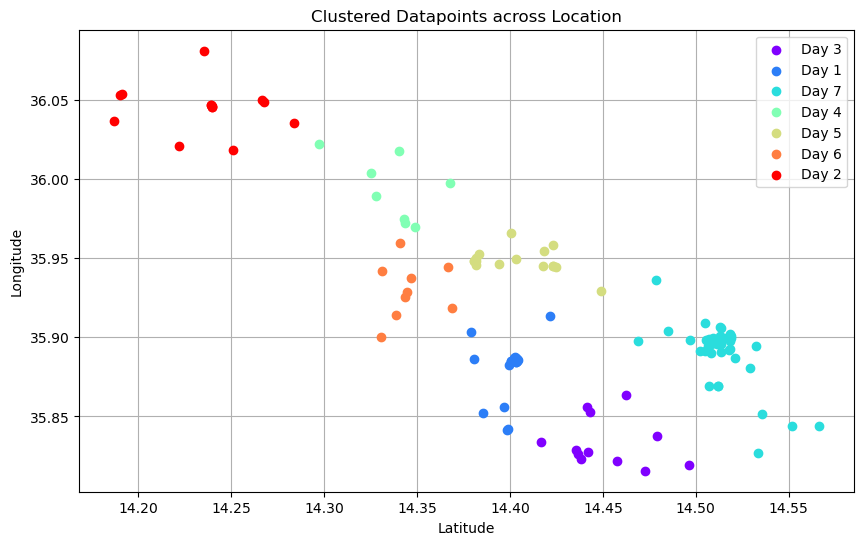

In [10]:
groups = df_places['Day'].unique()
colors = cm.rainbow(np.linspace(0, 1, len(groups)))

plt.figure(figsize=(10, 6))
for group, color in zip(groups, colors):
    group_data = df_places[df_places['Day'] == group]
    plt.scatter(group_data['Longitude'], group_data['Latitude'], label=f'Day {group+1}', color=color, zorder=2)

plt.title('Clustered Datapoints across Location')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.grid(zorder=1)
plt.legend()
plt.show()

In [11]:
for i in df_places['Day'].sort_values().unique():
    print(f'Day {i+1} Plan')
    print('-'*100)
    df_lim = df_places[df_places['Day'] == i]

    counter=0
    for _, row in df_lim.iterrows():
        print(f'Location {counter}: {row['Name']} --- {row['Address']} --- ({row['Types']})')
        counter+=1

    print('\n')

Day 1 Plan
----------------------------------------------------------------------------------------------------
Location 0: The Mdina Dungeons Museum --- St. Publius Square, L-Imdina, Malta --- (tourist_attraction, museum, point_of_interest, establishment)
Location 1: Tales of The Silent City --- Triq IL Villegaignon, L-Imdina, Malta --- (museum, tourist_attraction, point_of_interest, establishment)
Location 2: The Mdina Experience --- 7 Triq Mesquita, L-Imdina, Malta --- (tourist_attraction, bar, cafe, museum, food, point_of_interest, establishment)
Location 3: Mosta Valley --- WC7C+8J8, Constitution St, Mosta, Malta --- (tourist_attraction, point_of_interest, establishment)
Location 4: Mdina Cathedral Museum --- Archbishop's Square, L-Imdina MDN1061, Malta --- (tourist_attraction, museum, point_of_interest, establishment)
Location 5: Palazzo Falson --- Villegaignon Street, Triq IL Villegaignon, Mdina, Malta --- (museum, tourist_attraction, point_of_interest, establishment)
Location 6

# Find best path between points

In [12]:
day = 1
lim_df = df_places[df_places['Day']==day-1].drop(columns=['Day']).reset_index(drop=True)
lim_df

,Latitude,Longitude,Name,Address,Types,Day
0,35.884787,14.403527,The Mdina Dungeons Museum,"St. Publius Square, L-Imdina, Malta","tourist_attraction, museum, point_of_interest,...",0
1,35.885942,14.403278,Tales of The Silent City,"Triq IL Villegaignon, L-Imdina, Malta","museum, tourist_attraction, point_of_interest,...",0
2,35.885941,14.402552,The Mdina Experience,"7 Triq Mesquita, L-Imdina, Malta","tourist_attraction, bar, cafe, museum, food, p...",0
3,35.913287,14.421586,Mosta Valley,"WC7C+8J8, Constitution St, Mosta, Malta","tourist_attraction, point_of_interest, establi...",0
4,35.886017,14.404062,Mdina Cathedral Museum,"Archbishop's Square, L-Imdina MDN1061, Malta","tourist_attraction, museum, point_of_interest,...",0
5,35.887032,14.403092,Palazzo Falson,"Villegaignon Street, Triq IL Villegaignon, Mdi...","museum, tourist_attraction, point_of_interest,...",0
6,35.886413,14.403800,St. Paul's Cathedral,"2 Triq San Pawl, L-Imdina MDN 1061, Malta","tourist_attraction, museum, church, place_of_w...",0
7,35.884195,14.402997,Horse and Carriage,"VCM3+M5H, Rabat, Malta","tourist_attraction, point_of_interest, establi...",0
8,35.882854,14.399404,Casa Bernard,"46 Triq San Pawl, Ir-Rabat, Malta","tourist_attraction, museum, point_of_interest,...",0
9,35.884734,14.403447,Mdina Gate,"VCM3+V9W, Mdina, Malta","tourist_attraction, point_of_interest, establi...",0


### Fetch google maps travel time

In [57]:
def get_travel_distance_and_time(df, api_key):
    neighbour_holder = {}
    
    for index, row in df.iterrows():
        origin = f"{row['Latitude']},{row['Longitude']}"
        origin_name = row['Name']
        neighbour_holder[origin_name] = {}

        destination_groups = df.groupby(df.index // 5)

        for _, dfg in destination_groups:
            destinations_names = dfg[dfg['Name'] != origin_name]['Name'].values
            destinations_lst = dfg[dfg['Name'] != origin_name][['Latitude','Longitude']].values
            destinations = [f"{lat},{lng}" for (lat, lng) in destinations_lst]
            destinations_str = '|'.join(destinations)
            url = f"https://maps.googleapis.com/maps/api/distancematrix/json?origins={origin}&destinations={destinations_str}&key={api_key}"
        
            response = requests.get(url)
            data = response.json()
    
            for row in data['rows']:
                for index, element in enumerate(row['elements']):
                    if element['status'] == 'OK':
                        neighbour_holder[origin_name][destinations_names[index]] = [element['distance'], element['duration']]
                    else:
                        neighbour_holder[origin_name][destinations_names[index]] = [None, None]
   
    return neighbour_holder

raw_path_data = get_travel_distance_and_time(lim_df, api_key)

In [ ]:
with open('raw_path_data.pkl', 'wb') as f:
    pickle.dump(raw_path_data, f)

### Genetic Algorithm to find best paths 

In [41]:
# Genetic Algorithm (Evolutionary Computation - Not guarenteed optimal but efficient)
def generate_random_population(json_data):
    init_pop=[]

    chromosomes=list(json_data.keys())
    for i in range(1,301):
        random.shuffle(chromosomes)
        if chromosomes not in init_pop:
            init_pop.append(chromosomes.copy())
    
    return init_pop

def duration_fitness_score(chromosomes, json_data):
    overall_duration=0
    for index, chromosome in enumerate(chromosomes[:-1]):
        overall_duration += json_data[chromosome][chromosomes[index+1]][1]['value'] # Duration value

    return overall_duration


def adjust_fitness_scores(scores):
    max_fitness = max(scores)
    inverted_fitness=[(max_fitness - score) for score in scores]
    
    total_inverted_fitness=sum(inverted_fitness)
    selection_chance = [fit / total_inverted_fitness for fit in inverted_fitness]

    return selection_chance

def random_parent_selection(population,scores):
    parent = random.choices(population, weights=scores, k=1)[0]
    return parent

def fitness_diversity_selection(chromosome, population):
    # Calculate diversity based on number of different items in position
    current_candidate = ["",0]

    for parent_candidate in population:
        diversity_score = sum(1 for x, y in zip(chromosome, parent_candidate) if x != y) # Hamming distance

        if diversity_score > current_candidate[1]:
            current_candidate[0:2] = parent_candidate, diversity_score

    return current_candidate[0]

def crossover_operation(parent_1, parent_2):
    index1 = random.randint(0, len(parent_1) - 2)
    index2 = random.randint(index1 + 1, len(parent_1) - 1)

    segment = parent_1[index1:index2 + 1]
    remaining_values = [val for val in parent_2 if val not in segment]
    child1 = remaining_values[:index1] + segment + remaining_values[index1:]

    segment = parent_2[index1:index2 + 1]
    remaining_values = [val for val in parent_1 if val not in segment]
    child2 = remaining_values[:index1] + segment + remaining_values[index1:]

    return child_1, child_2

def mutation_operation(child):
    indices = list(range(len(child)))

    index1 = random.choice(indices)
    indices.remove(index1)
    index2 = random.choice(indices)

    child[index1], child[index2] = child[index2], child[index1]

    return child

In [64]:
init_rand_pop = generate_random_population(raw_path_data)
init_pop_scores = [duration_fitness_score(chromosomes, raw_path_data) for chromosomes in init_rand_pop]
avg_score = sum(init_pop_scores)/len(init_pop_scores)

avg_scores=[avg_score]
horizontal_axis=[i for i in range(0,len(avg_scores))]

#plt.figure(figsize=(8, 6))
#plt.ion()

population = init_rand_pop.copy()
scores = init_pop_scores.copy()
generation_count = 0

local_optimum_check = 0
best_overall_score = 0
while True:
    weighted_scores = adjust_fitness_scores(scores)
    new_population = []
    new_scores = [] 

    while len(new_population) < len(init_rand_pop):
        # Parent Selection
        parent_1 = random_parent_selection(population,weighted_scores)
        #parent_2 = random_parent_selection(population,weighted_scores)
        parent_2 = fitness_diversity_selection(parent_1, population)

        # Crossover
        crossover_probability=random.random()
        if crossover_probability > 0.6:
            child_1, child_2 = crossover_operation(parent_1,parent_2)
        else:
            child_1, child_2 = parent_1[:], parent_2[:]
        
        # Mutation
        child_1 = mutation_operation(child_1)
        child_2 = mutation_operation(child_2)

        if child_1 not in new_population and child_1 not in population:
            new_population.append(child_1)
            child_1_score = duration_fitness_score(child_1, raw_path_data)
            new_scores.append(child_1_score)
            

        if child_2 not in new_population and child_2 not in population:
            new_population.append(child_2)
            child_2_score = duration_fitness_score(child_2, raw_path_data)
            new_scores.append(child_2_score)

    top_individuals = 50
    sorted_new_population = sorted(zip(new_population, new_scores), key=lambda x: x[1])
    sorted_old_population = sorted(zip(population, scores), key=lambda x: x[1])
    best_new_individuals = sorted_new_population[:top_individuals]
    sorted_old_population[-top_individuals:] = best_new_individuals

    population, scores = zip(*sorted_old_population)
    population = list(population)
    scores = list(scores)

    avg_score = sum(scores) / len(population)
    avg_scores.append(avg_score)

    #horizontal_axis.append(generation_count + 1)

    #plt.clf()
    #plt.plot(horizontal_axis, avg_scores, marker='o', linestyle='-')
    #plt.xlabel('Generation')
    #plt.ylabel('Average Trip Duration')
    #plt.title('Average Fitness Score Over Generations (300 POP)')
    #plt.draw()
    #plt.pause(0.1) 

    print(f"Generation {generation_count}: Average Score: {avg_score}")
    sorted_population = sorted(zip(population, scores), key=lambda x: x[1])
    for i, (indiv, score) in enumerate(sorted_population[:3]):
        print(f"  {i + 1}. Individual: {indiv}, Duration: {score}")

    best_individual_score = sorted_population[0][1]
    if generation_count == 0:
        best_overall_score = best_individual_score
    else:
        if best_individual_score >= best_overall_score:
            local_optimum_check +=1

            if local_optimum_check == 100:
                break
        else:
            best_overall_score = best_individual_score
            local_optimum_check = 0

    generation_count += 1
    print("")
    
best_identified_path = sorted_population[0][0]
print(f'Start location: {sorted_population[0][0][0]}')
for index, location in enumerate(best_identified_path[1:]):
    if index < len(best_identified_path)-2:
        print(f'Location {index+1}: {location}')
    else:
        print(f'Final Location {index+1}: {location} - Total estimated route time: {sorted_population[0][1]/60:.2f} mins')

Generation 0: Average Score: 9150.456666666667
  1. Individual: ['Chadwick Lakes Nature Trail', 'Malta Fun Train Rabat', 'Tales of The Silent City', 'Mdina Cathedral Museum', 'Pjazza Mesquita', 'Bronze Age Grain Silos', 'Dingli cliffs viewpoint', 'The Mdina Dungeons Museum', 'Palazz Vilhena', 'The Mdina Experience', 'The Knights Of Malta', 'Palazzo Falson', 'Bastion Square', 'Casa Bernard', 'Domvs Romana', 'Horse and Carriage', 'Victoria Lines', 'Mosta Valley', 'Buskett Woods', 'Dingli Cliffs', 'Palazzo Santa Sofia', 'Mdina Gate', "St. Paul's Cathedral"], Duration: 6602
  2. Individual: ['Chadwick Lakes Nature Trail', 'Malta Fun Train Rabat', 'Domvs Romana', 'Casa Bernard', 'Pjazza Mesquita', 'Bronze Age Grain Silos', 'Dingli cliffs viewpoint', 'The Mdina Dungeons Museum', 'Palazz Vilhena', 'The Mdina Experience', 'The Knights Of Malta', 'Palazzo Falson', 'Bastion Square', 'Mdina Cathedral Museum', 'Tales of The Silent City', 'Horse and Carriage', 'Victoria Lines', 'Mosta Valley', 'Bus